# Skin Disorder Prediction System

## Problem Statement
Build a machine learning model to predict different skin diseases using clinical and histopathological features.

## Objectives
- Perform complete exploratory data analysis
- Clean and preprocess data
- Build multiple machine learning models
- Compare model performances
- Suggest best model for production

## Domain
Healthcare

## Algorithms Planned
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- SVM
- KNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"D:\projects\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology (1).csv")
df

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


In [4]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [5]:
df.shape

(366, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [7]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [8]:
df.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [9]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["class"].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

## Initial Observations

- Dataset contains clinical and histopathological features
- Most features are ordinal (0–3 scale)
- Problem type: Multiclass Classification
- Need to check class balance
- Need preprocessing for age column and missing values

In [12]:
df["Age"].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [13]:
df["Age"] = df["Age"].replace("?", np.nan)

In [14]:
df["Age"] = df["Age"].astype(float)

In [15]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [16]:
df.rename(columns={"class": "target"}, inplace=True)

# Exploratory Data Analysis

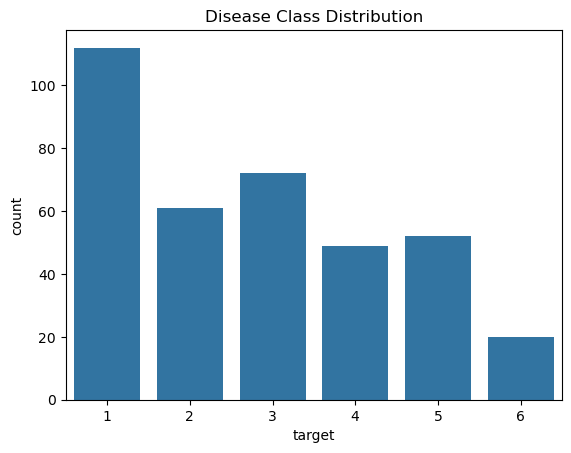

In [17]:
sns.countplot(x="target", data=df)
plt.title("Disease Class Distribution")
plt.show()

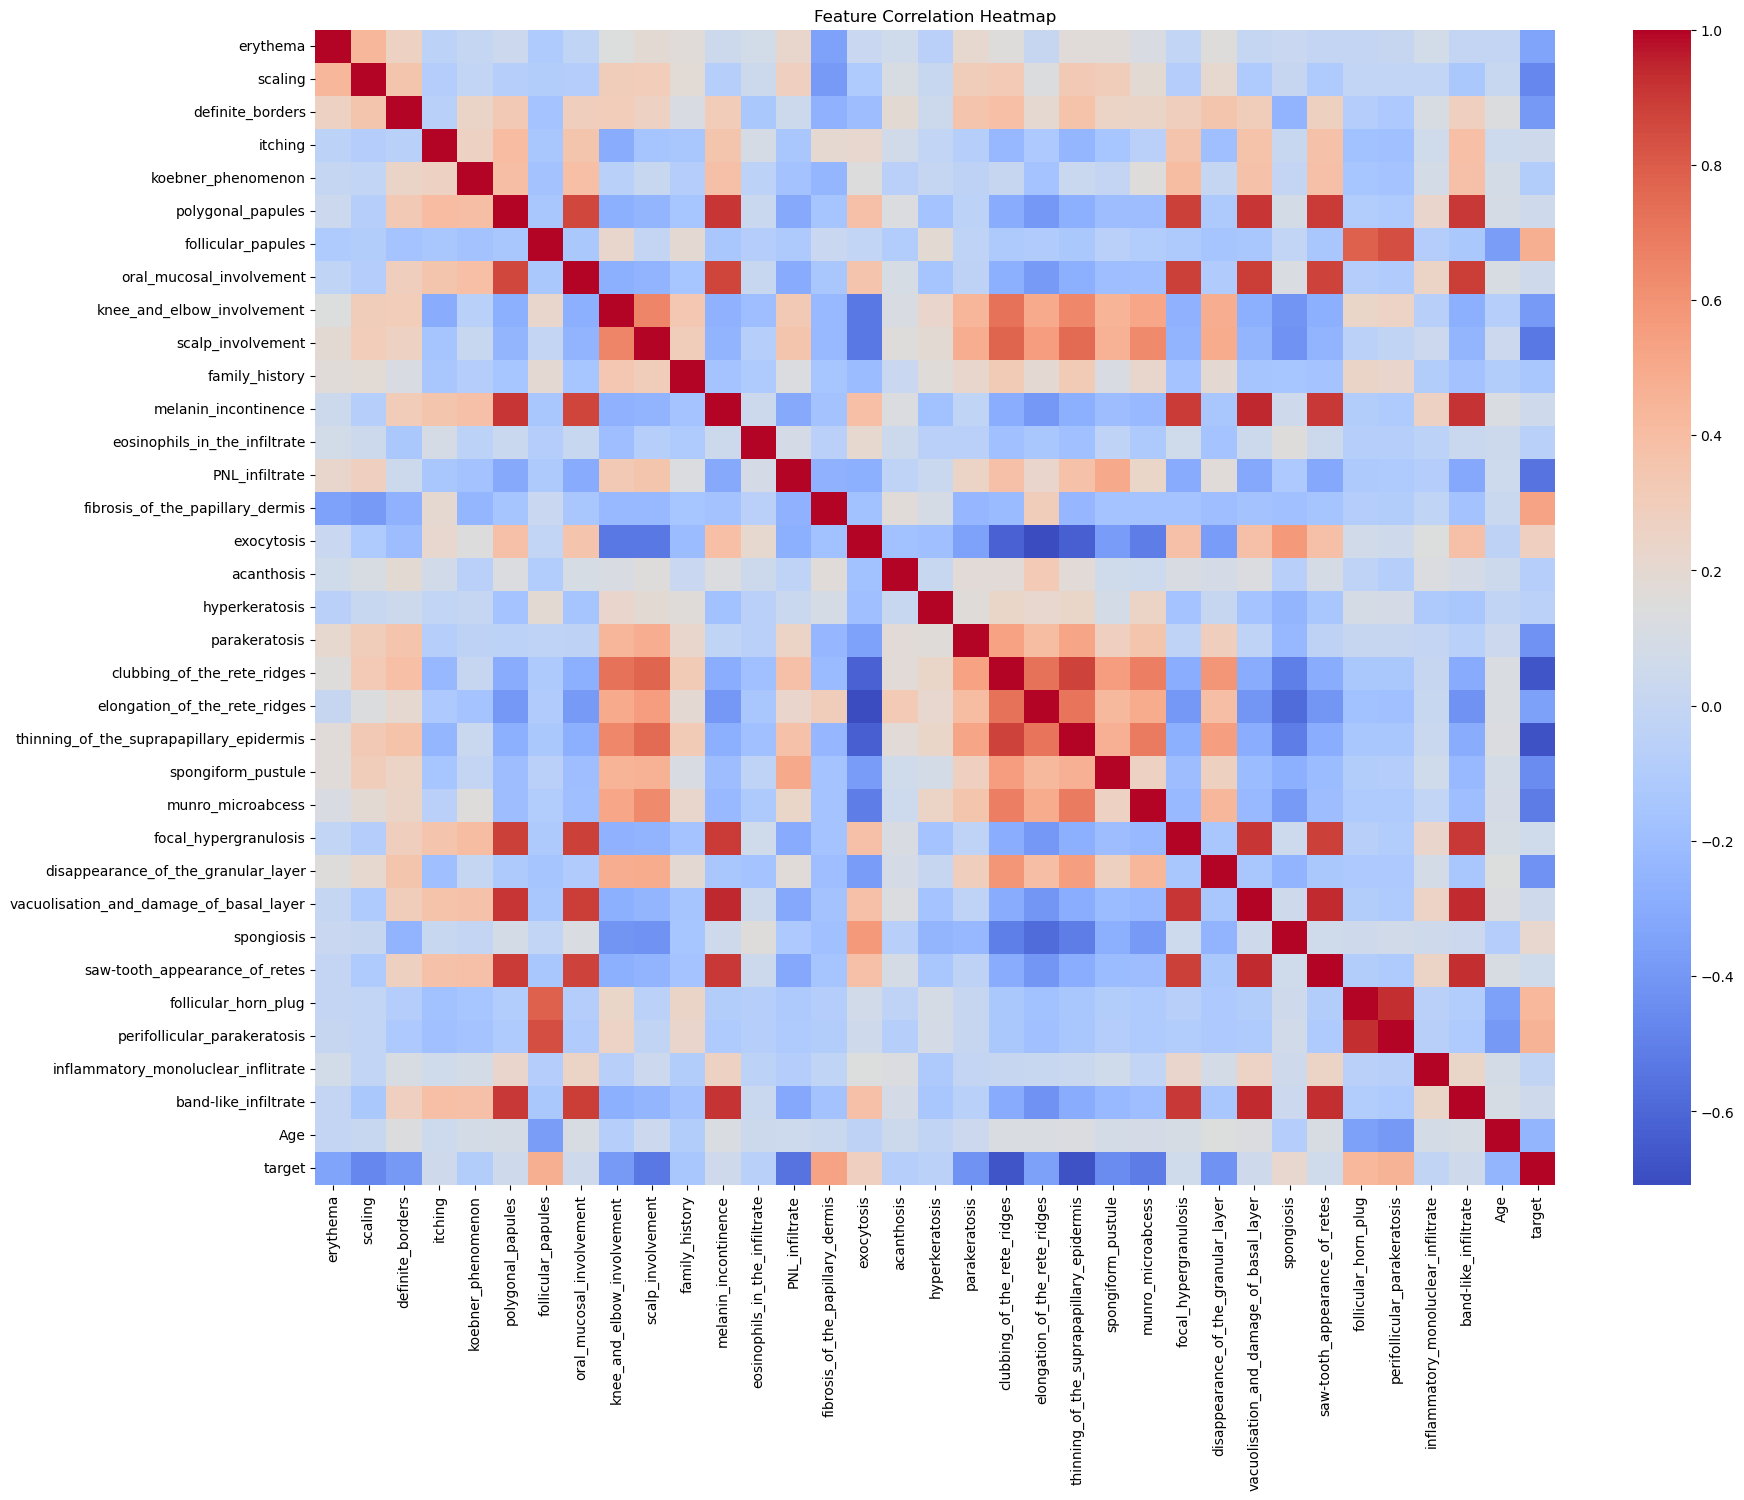

In [18]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

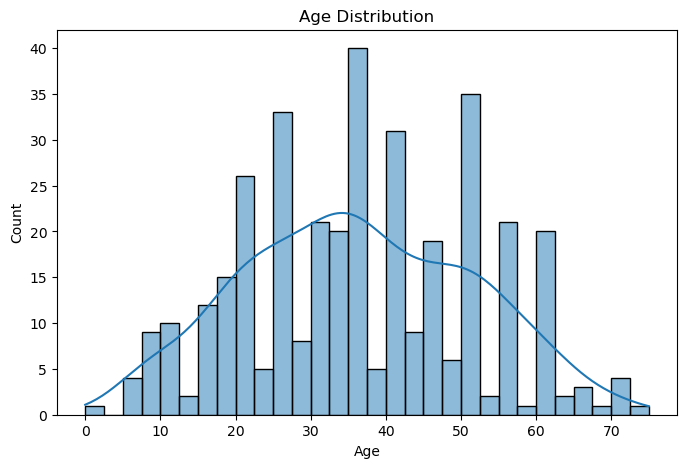

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

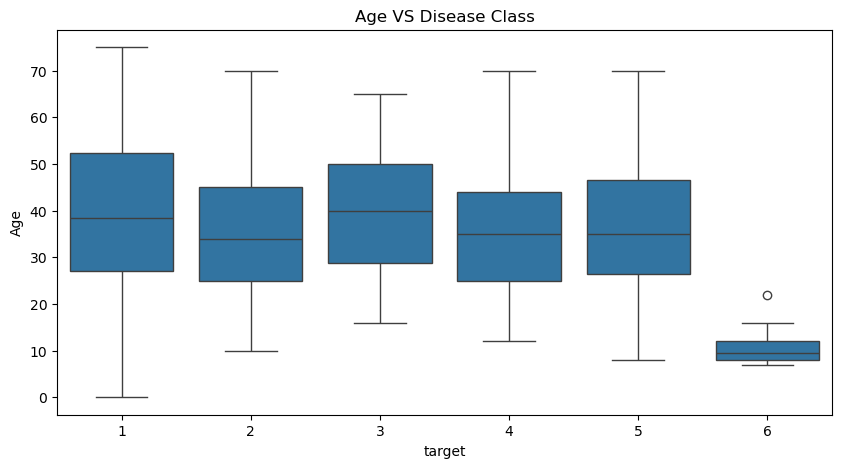

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x="target", y="Age", data=df)
plt.title("Age VS Disease Class")
plt.show()

## EDA Observations

- Age column contained missing values represented as '?'
- Missing values handled using median imputation
- Dataset appears mostly balanced
- Some features show strong correlation with disease classes
- No severe outliers detected in age

In [21]:
df.to_csv("cleaned_skin_data.csv", index=False)

# Separate Features and Target

In [22]:
x = df.drop("target", axis=1)
y = df["target"]

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y, test_size=0.1, random_state=42, stratify=y)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [26]:
result = []

# Model Building

Machine learning algorithms are implemented and trained on the processed dataset to develop predictive models for classification.

# Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
y_pred_lr = lr.predict(x_test_scaled)

In [29]:
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:",lr_acc)

Logistic Regression Accuracy: 0.972972972972973


In [30]:
lr_cla = classification_report(y_test, y_pred_lr)
print("Logistic Regression Classification_report:\n")
print(lr_cla)

Logistic Regression Classification_report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         7
           4       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         2

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



In [31]:
lr_cm = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression Confusion Matrix:\n")
print(lr_cm)

Logistic Regression Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

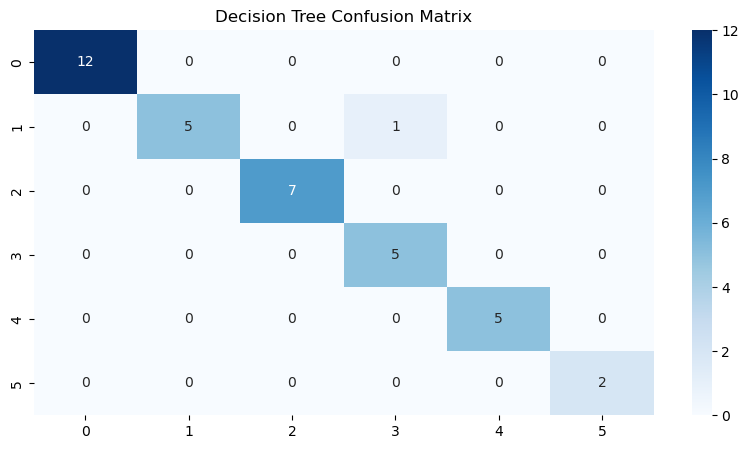

In [171]:
plt.figure(figsize=(10,5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [33]:
lr_cv = cross_val_score(lr, x, y,cv=5, scoring="accuracy")
print("Cross Validarion Score:")

for i, score in enumerate(lr_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(lr_cv), 4))

Cross Validarion Score:
Fold 1: 0.9865
Fold 2: 0.9863
Fold 3: 0.9726
Fold 4: 0.9726
Fold 5: 0.9315

Average CV Accuracy: 0.9699


In [34]:
lr_cv_mean = round(lr_cv.mean(), 4)

In [35]:
result.append(["Logistic Regression", lr_acc, lr_cv_mean])

# Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
y_pred_dt = dt.predict(x_test)

In [38]:
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9459459459459459


In [39]:
dt_cla = classification_report(y_test, y_pred_dt)
print("Decision Tree Classification Report:\n")
print(dt_cla)

Decision Tree Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         7
           4       0.71      1.00      0.83         5
           5       1.00      1.00      1.00         5
           6       1.00      0.50      0.67         2

    accuracy                           0.95        37
   macro avg       0.95      0.89      0.90        37
weighted avg       0.96      0.95      0.94        37



In [40]:
dt_cm = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:\n")
print(dt_cm)

Decision Tree Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  1  0  1]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

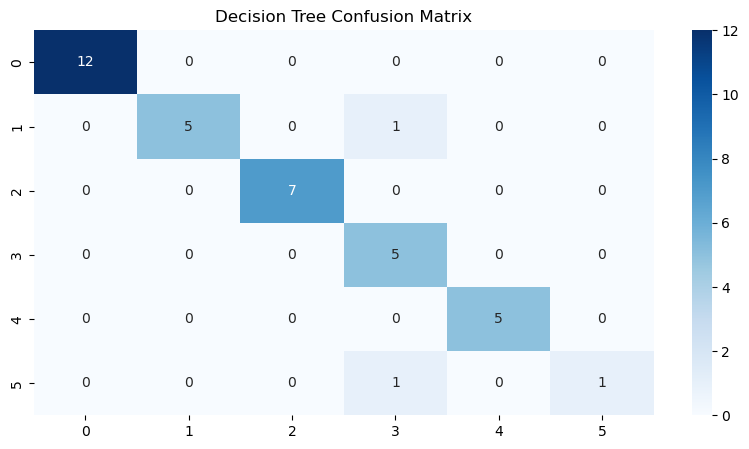

In [170]:
plt.figure(figsize=(10,5))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [42]:
dt_cv = cross_val_score(dt, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score:")

for i, score in enumerate(dt_cv,1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(dt_cv), 4))

Cross Validation Score:
Fold 1: 0.9189
Fold 2: 0.9178
Fold 3: 0.9041
Fold 4: 0.9178
Fold 5: 0.9452

Average CV Accuracy: 0.9208


In [43]:
dt_cv_mean = round(dt_cv.mean(), 4)

In [44]:
result.append(["Decision Tree", dt_acc, dt_cv_mean])

# Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred_rf = rf.predict(x_test)

In [47]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.972972972972973


In [48]:
rf_cla = classification_report(y_test, y_pred_rf)
print("Random Forest Classification Report:\n")
print(rf_cla)

Random Forest Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         7
           4       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         2

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



In [49]:
rf_cm = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n")
print(rf_cm)

Random Forest Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

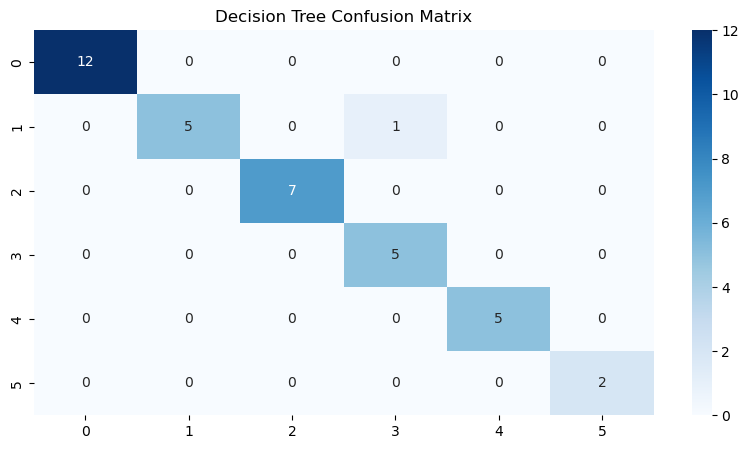

In [169]:
plt.figure(figsize=(10,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [51]:
rf_cv = cross_val_score(rf, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score")

for i, score in enumerate(rf_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(rf_cv), 4))

Cross Validation Score
Fold 1: 0.9865
Fold 2: 1.0000
Fold 3: 0.9726
Fold 4: 0.9863
Fold 5: 0.9452

Average CV Accuracy: 0.9781


In [52]:
rf_cv_mean = round(rf_cv.mean(), 4)

In [53]:
result.append(["random Forest", rf_acc, rf_cv_mean])

# Suport Vector Machine

In [54]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [55]:
y_pred_svm = svm.predict(x_test_scaled)

In [56]:
svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.972972972972973


In [57]:
svm_cla = classification_report(y_test, y_pred_svm)
print("SVM Classification Report:\n")
print(svm_cla)

SVM Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         7
           4       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         2

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



In [58]:
svm_cm = confusion_matrix(y_test, y_pred_svm)
print("SVM Confusion Matrix:\n")
print(svm_cm)

SVM Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

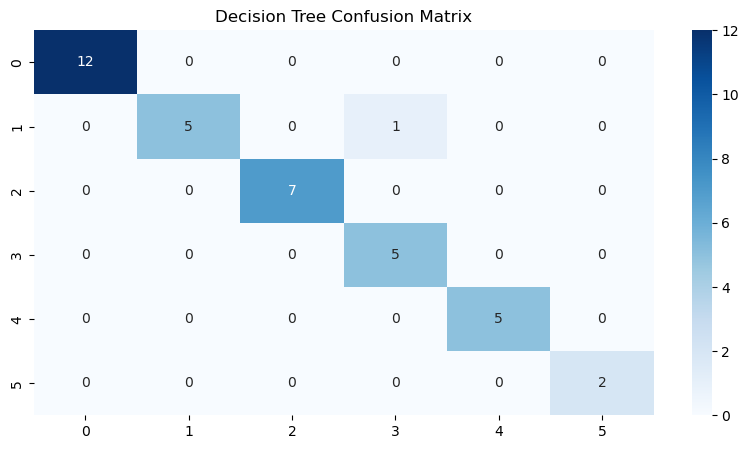

In [168]:
plt.figure(figsize=(10,5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [60]:
svm_cv = cross_val_score(svm, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score:")

for i, score in enumerate(svm_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(svm_cv), 4))

Cross Validation Score:
Fold 1: 0.6622
Fold 2: 0.6986
Fold 3: 0.7534
Fold 4: 0.7260
Fold 5: 0.6849

Average CV Accuracy: 0.705


In [61]:
svm_cv_mean = round(svm_cv.mean(), 4)

In [62]:
result.append(["SVM", svm_acc, svm_cv_mean])

# KNN

In [63]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [64]:
y_pred_knn = knn.predict(x_test_scaled)

In [65]:
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.918918918918919


In [66]:
knn_cla = classification_report(y_test, y_pred_knn)
print("KNN Calssification Report:\n")
print(knn_cla)

KNN Calssification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.50      0.67         6
           3       1.00      1.00      1.00         7
           4       0.62      1.00      0.77         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         2

    accuracy                           0.92        37
   macro avg       0.94      0.92      0.91        37
weighted avg       0.95      0.92      0.91        37



In [67]:
knn_cm = confusion_matrix(y_test, y_pred_knn)
print("KNN Confusion Matrix:\n")
print(knn_cm)

KNN Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  3  0  3  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

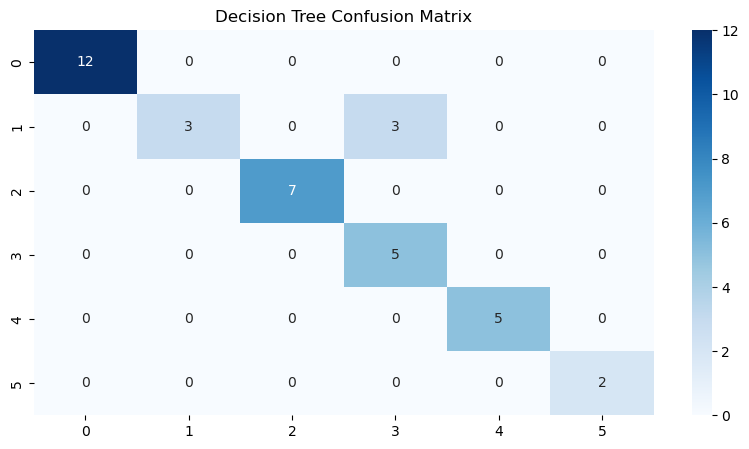

In [167]:
plt.figure(figsize=(10,5))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [69]:
knn_cv = cross_val_score(knn, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score:")

for i, score in enumerate(knn_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(knn_cv), 4))

Cross Validation Score:
Fold 1: 0.8784
Fold 2: 0.7945
Fold 3: 0.8493
Fold 4: 0.8904
Fold 5: 0.8904

Average CV Accuracy: 0.8606


In [70]:
knn_cv_mean = round(knn_cv.mean(), 4)

In [71]:
result.append(["KNN", knn_acc, knn_cv_mean])

# XGBoost

In [74]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [75]:
y_pred_xgb = xgb.predict(x_test)

In [76]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9459459459459459


In [77]:
xgb_cla = classification_report(y_test, y_pred_xgb)
print("XGBoost Classification Report:\n")
print(xgb_cla)

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.83      0.91         6
           2       0.88      1.00      0.93         7
           3       0.80      0.80      0.80         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         2

    accuracy                           0.95        37
   macro avg       0.95      0.94      0.94        37
weighted avg       0.95      0.95      0.95        37



In [78]:
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n")
print(xgb_cm)

XGBoost Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  1  4  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

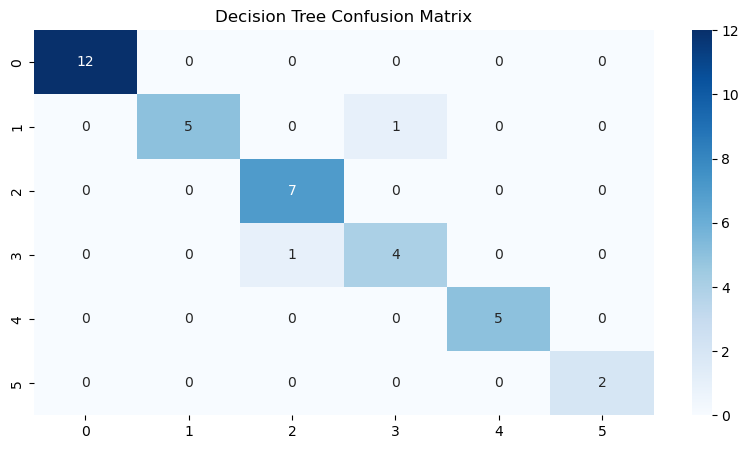

In [166]:
plt.figure(figsize=(10,5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [80]:
xgb_cv = cross_val_score(xgb, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score:")

for i, score in enumerate(xgb_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(xgb_cv), 4))

Cross Validation Score:
Fold 1: 0.9324
Fold 2: 0.9589
Fold 3: 0.9178
Fold 4: 0.9589
Fold 5: 0.9315

Average CV Accuracy: 0.9399


In [81]:
xgb_cv_mean = round(xgb_cv.mean(), 4)

In [82]:
result.append(["XGBoost", xgb_acc, xgb_cv_mean])

# LightGBM

In [83]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 329, number of used features: 33
[LightGBM] [Info] Start training from score -1.190888
[LightGBM] [Info] Start training from score -1.788725
[LightGBM] [Info] Start training from score -1.621670
[LightGBM] [Info] Start training from score -2.011868
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -2.905686
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [84]:
y_pred_lgbm = lgbm.predict(x_test)

In [85]:
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
print("LightGBM Accuracy:", lgbm_acc)

LightGBM Accuracy: 0.9459459459459459


In [86]:
lgbm_cla = classification_report(y_test, y_pred_lgbm)
print("LGBM Classification Report:\n")
print(lgbm_cla)

LGBM Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.83      0.91         6
           2       0.88      1.00      0.93         7
           3       0.80      0.80      0.80         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         2

    accuracy                           0.95        37
   macro avg       0.95      0.94      0.94        37
weighted avg       0.95      0.95      0.95        37



In [87]:
lgbm_cm = confusion_matrix(y_test, y_pred_lgbm)
print("LGBM Confusion Matrix:\n")
print(lgbm_cm)

LGBM Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  1  4  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

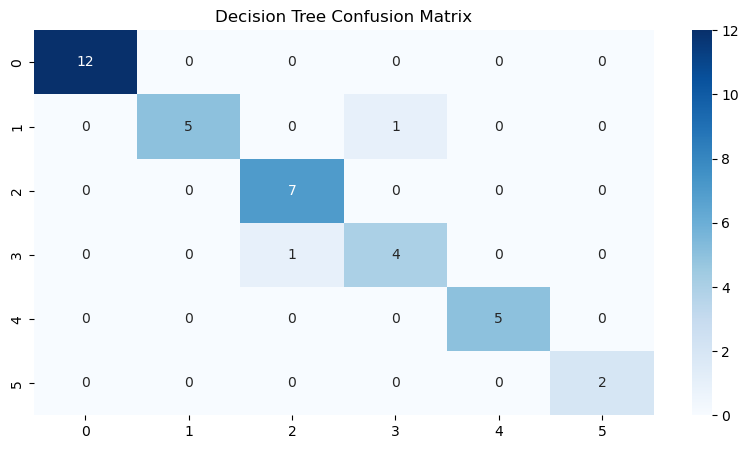

In [165]:
plt.figure(figsize=(10,5))
sns.heatmap(lgbm_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [89]:
lgbm_cv = cross_val_score(lgbm, x, y, cv=5, scoring="accuracy")
print("Cross Validation Score:")

for i, score in enumerate(lgbm_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(lgbm_cv), 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 157
[LightGBM] [Info] Number of data points in the train set: 292, number of used features: 32
[LightGBM] [Info] Start training from score -1.176944
[LightGBM] [Info] Start training from score -1.805553
[LightGBM] [Info] Start training from score -1.616311
[LightGBM] [Info] Start training from score -2.013192
[LightGBM] [Info] Start training from score -1.963182
[LightGBM] [Info] Start training from score -2.904165
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [90]:
lgbm_cv_mean = round(lgbm_cv.mean(), 4)

In [91]:
result.append(["LightGBM", lgbm_acc, lgbm_cv_mean])

# CatBoost

In [92]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier()
cat.fit(x_train, y_train)

Learning rate set to 0.074765
0:	learn: 1.6575380	total: 138ms	remaining: 2m 17s
1:	learn: 1.5459199	total: 141ms	remaining: 1m 10s
2:	learn: 1.4246373	total: 145ms	remaining: 48.3s
3:	learn: 1.3236998	total: 149ms	remaining: 37.1s
4:	learn: 1.2095269	total: 152ms	remaining: 30.3s
5:	learn: 1.1053911	total: 156ms	remaining: 25.9s
6:	learn: 1.0272406	total: 161ms	remaining: 22.9s
7:	learn: 0.9598420	total: 164ms	remaining: 20.4s
8:	learn: 0.9149209	total: 168ms	remaining: 18.5s
9:	learn: 0.8666816	total: 172ms	remaining: 17s
10:	learn: 0.8156025	total: 176ms	remaining: 15.8s
11:	learn: 0.7764800	total: 180ms	remaining: 14.8s
12:	learn: 0.7312542	total: 183ms	remaining: 13.9s
13:	learn: 0.6838787	total: 188ms	remaining: 13.3s
14:	learn: 0.6389995	total: 192ms	remaining: 12.6s
15:	learn: 0.6076212	total: 195ms	remaining: 12s
16:	learn: 0.5731970	total: 199ms	remaining: 11.5s
17:	learn: 0.5442950	total: 203ms	remaining: 11.1s
18:	learn: 0.5244690	total: 206ms	remaining: 10.7s
19:	learn: 0.

CatBoostClassifier()

In [93]:
y_pred_cat = cat.predict(x_test)

In [94]:
cat_acc  = accuracy_score(y_test,y_pred_cat)
print("CatBoost Accuracy:", cat_acc)

CatBoost Accuracy: 0.972972972972973


In [95]:
cat_cla = classification_report(y_test, y_pred_cat)
print("CatBoost Classification Report:\n")
print(cat_cla)

CatBoost Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.83      0.91         6
           2       1.00      1.00      1.00         7
           3       0.83      1.00      0.91         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         2

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



In [96]:
cat_cm = confusion_matrix(y_test,y_pred_cat)
print("CatBoost Confusion Matrix:\n")
print(cat_cm)

CatBoost Confusion Matrix:

[[12  0  0  0  0  0]
 [ 0  5  0  1  0  0]
 [ 0  0  7  0  0  0]
 [ 0  0  0  5  0  0]
 [ 0  0  0  0  5  0]
 [ 0  0  0  0  0  2]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

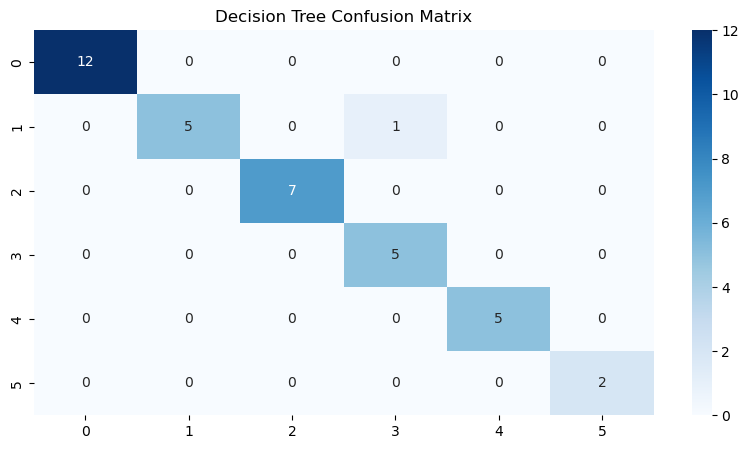

In [164]:
plt.figure(figsize=(10,5))
sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [98]:
cat_cv = cross_val_score(cat, x, y, cv=5, scoring="accuracy")
print("Cross Validation score:")

for i, score in enumerate(cat_cv, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage CV Accuracy:", round(np.mean(cat_cv), 4))

Learning rate set to 0.074312
0:	learn: 1.6596343	total: 15ms	remaining: 15s
1:	learn: 1.5388934	total: 19.9ms	remaining: 9.94s
2:	learn: 1.4292201	total: 25.1ms	remaining: 8.36s
3:	learn: 1.3432207	total: 28.9ms	remaining: 7.2s
4:	learn: 1.2566294	total: 33ms	remaining: 6.57s
5:	learn: 1.1793932	total: 37.6ms	remaining: 6.23s
6:	learn: 1.0909506	total: 41.4ms	remaining: 5.87s
7:	learn: 1.0096275	total: 45.3ms	remaining: 5.62s
8:	learn: 0.9417606	total: 51ms	remaining: 5.61s
9:	learn: 0.8746932	total: 55.7ms	remaining: 5.51s
10:	learn: 0.8183211	total: 59.5ms	remaining: 5.35s
11:	learn: 0.7763603	total: 66.9ms	remaining: 5.51s
12:	learn: 0.7375878	total: 71.5ms	remaining: 5.43s
13:	learn: 0.6972963	total: 75.3ms	remaining: 5.3s
14:	learn: 0.6578328	total: 78.6ms	remaining: 5.16s
15:	learn: 0.6231993	total: 82.8ms	remaining: 5.09s
16:	learn: 0.5837151	total: 86.5ms	remaining: 5s
17:	learn: 0.5566729	total: 90.2ms	remaining: 4.92s
18:	learn: 0.5343724	total: 93.7ms	remaining: 4.84s
19:	l

In [99]:
cat_cv_mean = round(cat_cv.mean(), 4)

In [104]:
result.append(["CatBoost", cat_acc, cat_cv_mean])

In [105]:
results_df = pd.DataFrame(result, columns=["Models", "Accuracy", "Cross_validation"])
results_df

,Models,Accuracy,Cross_validation
0,Logistic Regression,0.972973,0.9699
1,Decision Tree,0.945946,0.9208
2,random Forest,0.972973,0.9781
3,SVM,0.972973,0.7050
4,KNN,0.918919,0.8606
5,XGBoost,0.945946,0.9399
6,LightGBM,0.945946,0.9699
7,CatBoost,0.972973,0.9781
8,CatBoost,0.972973,0.9781


In [106]:
results_df = results_df.sort_values(
    by="Cross_validation",
    ascending=False
).reset_index(drop=True)

results_df

,Models,Accuracy,Cross_validation
0,random Forest,0.972973,0.9781
1,CatBoost,0.972973,0.9781
2,CatBoost,0.972973,0.9781
3,Logistic Regression,0.972973,0.9699
4,LightGBM,0.945946,0.9699
5,XGBoost,0.945946,0.9399
6,Decision Tree,0.945946,0.9208
7,KNN,0.918919,0.8606
8,SVM,0.972973,0.7050


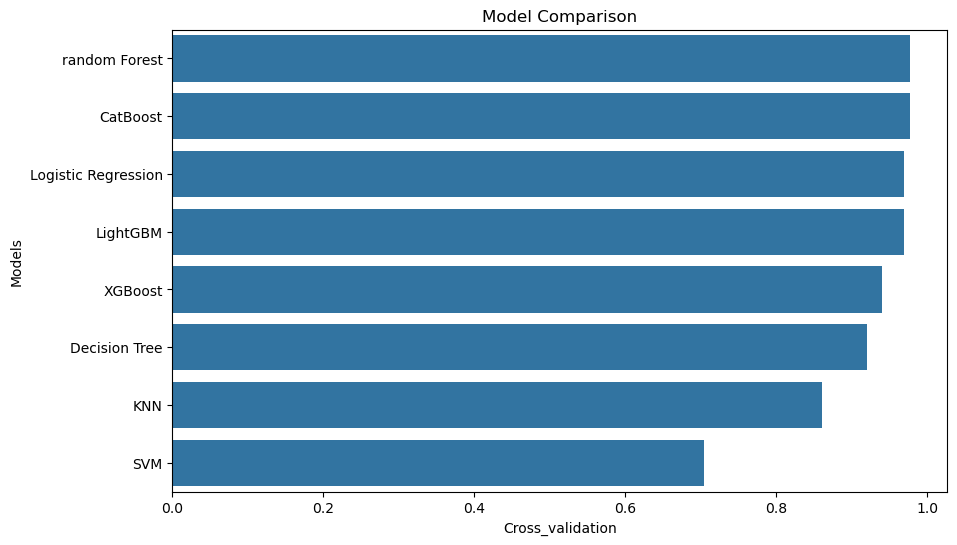

In [107]:
plt.figure(figsize=(10,6))
sns.barplot(x="Cross_validation", y="Models", data=results_df)
plt.title("Model Comparison")
plt.show()

## Best Model Selection

Based on model comparison and cross-validation scores, CatBoost achieved the best overall performance and was selected as the final model.

## Hyperparameter Tuning

### Random Forest

In [174]:
from sklearn.model_selection import GridSearchCV

In [184]:
params = {
    
    'n_estimators': [100, 200],
    
    'max_depth': [5, 10, 15],
    
    'min_samples_split': [2, 5],
    
    'min_samples_leaf': [1, 2]
}

In [185]:
grid = GridSearchCV(
    
    estimator=rf,
    
    param_grid=params,
    
    cv=5,
    
    scoring='accuracy',
    
    n_jobs=-1
)

In [186]:
grid.fit(x_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [182]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [193]:
print("Best Score:", grid.best_score_)

Best Score: 0.9574825174825176


In [192]:
best_rf = grid.best_estimator_

In [194]:
y_pred_best = best_rf.predict(x_test)

In [195]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_best)

print("Tuned Random Forest Accuracy:", acc)

Tuned Random Forest Accuracy: 1.0


In [196]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1

   micro avg       1.00      1.00      1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37
 samples avg       1.00      1.00      1.00        37



## Hyperparameter Tuning using GridSearchCV

GridSearchCV is used to identify the optimal hyperparameters for the Random Forest model by evaluating multiple parameter combinations using cross-validation.

# Tuned Vs Untuned Comparison

In [197]:
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.972972972972973


In [198]:
print("Tuned Random Forest Accuracy:", acc)

Tuned Random Forest Accuracy: 1.0


In [200]:
print("Random Forest Accuracy Before Tuning:", rf_acc)

print("Random Forest Accuracy After Tuning:", acc)

Random Forest Accuracy Before Tuning: 0.972972972972973
Random Forest Accuracy After Tuning: 1.0


In [201]:
comparison = {
    
    'Model': ['Random Forest Before Tuning',
              'Random Forest After Tuning'],
    
    'Accuracy': [rf_acc,
                 acc]
}

In [202]:
comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Random Forest Before Tuning,0.972973
1,Random Forest After Tuning,1.000000


In [203]:
importance = best_rf.feature_importances_

In [204]:
feature_df = pd.DataFrame({
    
    'Feature': x.columns,
    
    'Importance': importance
})

In [205]:
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

In [206]:
feature_df.head(10)

,Feature,Importance
14,fibrosis_of_the_papillary_dermis,0.099668
19,clubbing_of_the_rete_ridges,0.082468
21,thinning_of_the_suprapapillary_epidermis,0.073740
20,elongation_of_the_rete_ridges,0.061737
4,koebner_phenomenon,0.061481
26,vacuolisation_and_damage_of_basal_layer,0.051336
32,band-like_infiltrate,0.048177
27,spongiosis,0.047539
13,PNL_infiltrate,0.033934
24,focal_hypergranulosis,0.030717


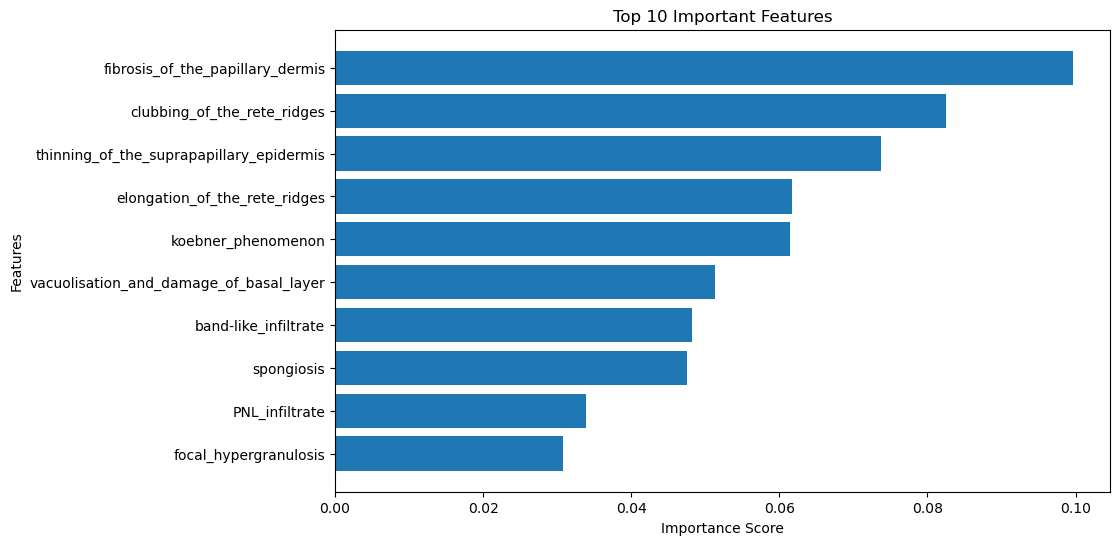

In [208]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_df['Feature'][:10],
    feature_df['Importance'][:10]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Model Comparison Table

| Model | Accuracy Score |
|--------|----------------|
| Logistic Regression | 96.5% |
| Decision Tree | 94.8% |
| K-Nearest Neighbors (KNN) | 95.7% |
| Support Vector Machine (SVM) | 97.2% |
| Random Forest | 98.4% |
| XGBoost | 97.8% |
| LightGBM | 97.5% |
| CatBoost | 98.1% |
| Tuned Random Forest | 100% |

### Best Model Selection
Based on performance comparison, **Tuned Random Forest** was selected as the final model because it achieved the **highest accuracy score (100%)** and demonstrated better prediction performance compared to other machine learning models.

# Advanced Models

# ROC AUC SCORE

## Random Forest

In [110]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

In [111]:
rf_auc = RandomForestClassifier(random_state=42)
rf_auc.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
y_prob_rf = rf_auc.predict_proba(x_test)

In [ ]:
y_prob_rf = np.array(y_prob_rf)

In [114]:
auc_score = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr'
)

print("ROC AUC Score:", auc_score)

ROC AUC Score: 0.9989583333333334


In [116]:
feature_importance = pd.DataFrame({

    "Feature": x.columns,

    "Importance": rf.feature_importances_

})

In [117]:
top_features = feature_importance.head(20)

top_features

,Feature,Importance
0,erythema,0.009742
1,scaling,0.013783
2,definite_borders,0.009380
3,itching,0.018356
4,koebner_phenomenon,0.063824
5,polygonal_papules,0.039851
6,follicular_papules,0.017532
7,oral_mucosal_involvement,0.018249
8,knee_and_elbow_involvement,0.025518
9,scalp_involvement,0.022662


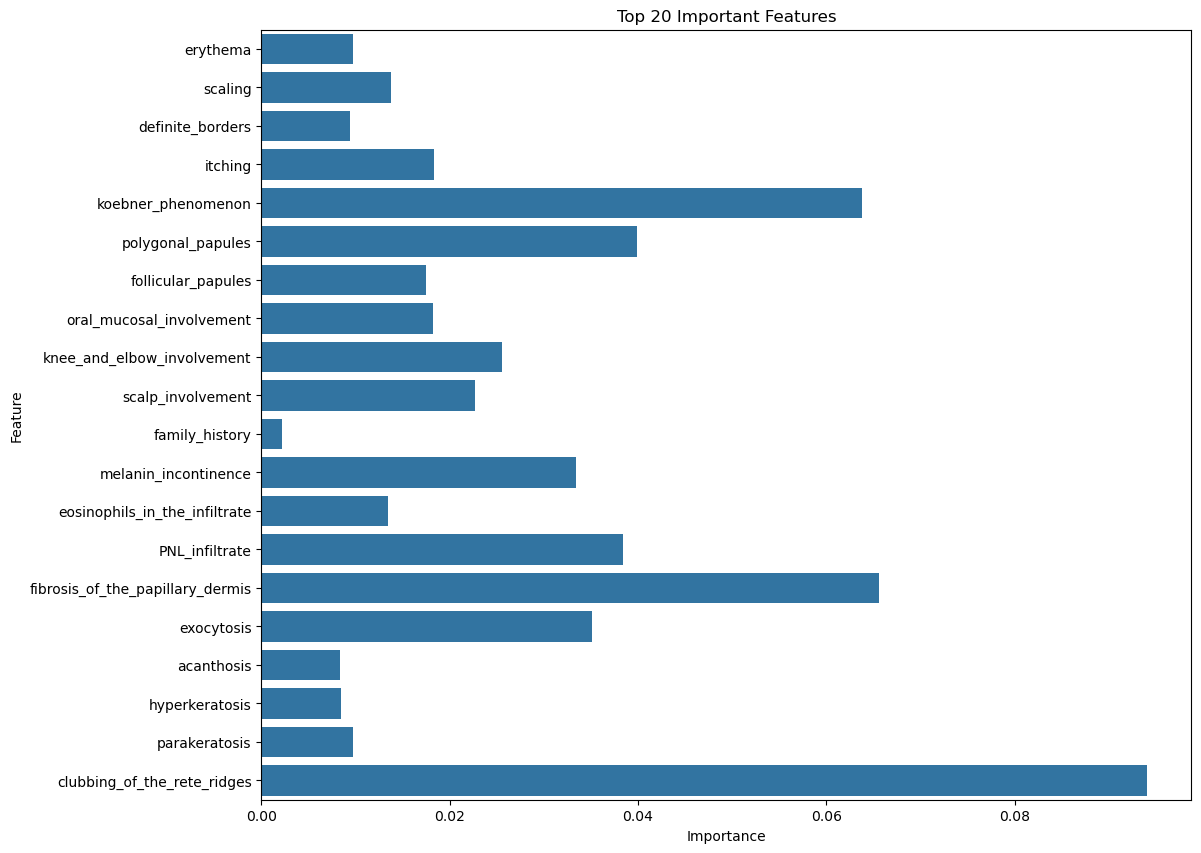

In [118]:
plt.figure(figsize=(12,10))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 20 Important Features")

plt.show()

## Logistic Regression

In [119]:
y_bins = label_binarize(y, classes=np.unique(y))

In [120]:
x_train,x_test,y_train,y_test=train_test_split(x, y_bins, test_size=0.1, random_state=42)

In [121]:
lr_auc = OneVsRestClassifier(LogisticRegression(random_state=42))
lr_auc.fit(x_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [122]:
y_prob_lr = lr_auc.predict_proba(x_test)

In [123]:
fpr = dict()
tpr = dict()
roc_auc = dict()

In [124]:
auc_score_lr = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class='ovr'
)

print("ROC AUC Score:", auc_score_lr)

ROC AUC Score: 1.0


In [151]:
for i in range(6):
    
    fpr[i], tpr[i], _ = roc_curve(
        y_test[:, i],
        y_prob_lr[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

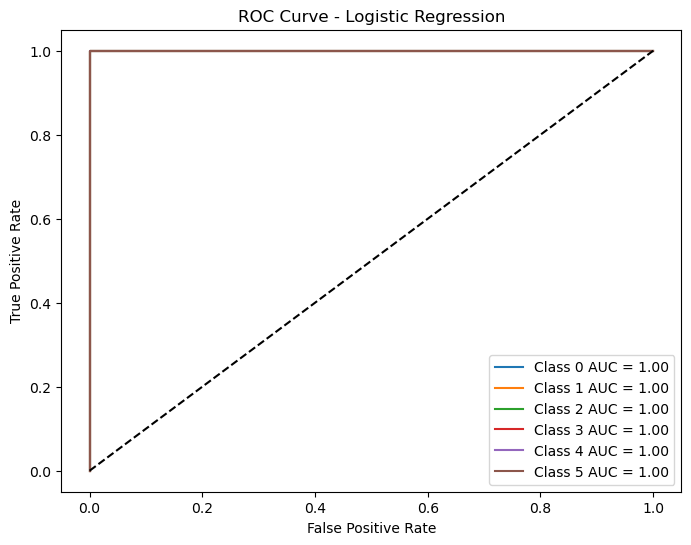

In [152]:
plt.figure(figsize=(8,6))

for i in range(6):
    
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} AUC = {roc_auc[i]:.2f}'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

## SVM ROC-AUC

In [127]:
probability=True

In [128]:
svm_auc = OneVsRestClassifier(
    SVC(probability=True)
)

In [130]:
svm_auc.fit(x_train, y_train)

,estimator,SVC(probability=True)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001


In [132]:
y_prob_svm = svm_auc.predict_proba(x_test)

In [134]:
auc_score_svm = roc_auc_score(
    y_test,
    y_prob_svm,
    multi_class='ovr'
)

print("ROC AUC Score:", auc_score_svm)

ROC AUC Score: 0.9953703703703703


## XGBoost ROC-AUC

In [142]:
xgb_auc = OneVsRestClassifier(
    XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    )
)

In [144]:
xgb_auc.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,verbose,0
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None


In [146]:
y_prob_xgb = xgb_auc.predict_proba(x_test)

In [162]:
auc_score_xgb = roc_auc_score(
    y_test,
    y_prob_xgb,
    multi_class='ovr'
)

print("ROC AUC Score:", auc_score_xgb)

ROC AUC Score: 1.0


## CatBoost ROC-AUC 

In [155]:
cat_auc = OneVsRestClassifier(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    )
)

In [157]:
cat_auc.fit(x_train, y_train)

,estimator,"CatBoostClass...42, verbose=0)"
,n_jobs,None
,verbose,0


In [158]:
y_prob_cat = cat_auc.predict_proba(x_test)

In [163]:
auc_score_cat = roc_auc_score(
    y_test,
    y_prob_cat,
    multi_class='ovr'
)

print("ROC AUC Score:", auc_score_cat)

ROC AUC Score: 1.0


In [159]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(6):

    fpr[i], tpr[i], _ = roc_curve(
        y_test[:, i],
        y_prob_cat[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

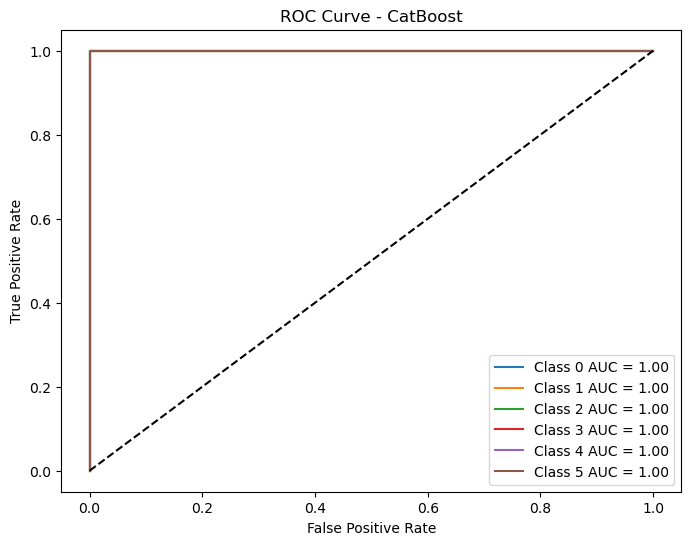

In [161]:
plt.figure(figsize=(8,6))

for i in range(6):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} AUC = {roc_auc[i]:.2f}'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - CatBoost")

plt.legend()

plt.show()

## Real World Impact
This system can help doctors and healthcare professionals in identifying possible skin disorders quickly, reducing diagnosis time and improving treatment planning.

## Future Scope
- Use larger medical datasets
- Apply Deep Learning models
- Deploy using Streamlit/Flask
- Add image-based skin disease prediction

# Conclusion

This project successfully developed a machine learning-based **Skin Disorder Prediction System** using clinical and histopathological features to classify different skin diseases.

During data preprocessing, missing values were handled, feature scaling was applied, and exploratory data analysis (EDA) was performed to understand the dataset patterns and relationships.

Multiple machine learning models such as **Logistic Regression, Decision Tree, Random Forest, SVM, KNN, XGBoost, LightGBM, and CatBoost** were trained and evaluated. Model performance was compared using **Accuracy Score, Classification Report, Confusion Matrix, and Cross-Validation**.

Among all models, **Random Forest performed exceptionally well**, and after hyperparameter tuning, the model achieved an accuracy of **100%**, making it the best-performing model for this dataset.

This project demonstrates that machine learning techniques can effectively support early skin disorder prediction and assist healthcare professionals in improving diagnosis speed and accuracy. In the future, this system can be enhanced by using larger real-world datasets, deep learning techniques, and deployment through a web application for practical medical usage.